=== Summary (Stage 2 focus) ===
[scenario1]
  mean_reward_last50_stage2: -5.999999999999995
  mean_steps_last50_stage2: 60.0
  episodes_to_mastery_stage1: None
  episodes_to_mastery_stage2: None
[scenario2_dyad]
  mean_reward_last50_stage2: -5.999999999999995
  mean_steps_last50_stage2: 60.0
  episodes_to_mastery_stage1_A: None
  episodes_to_mastery_stage1_B: None
  episodes_to_mastery_stage2_dyad: None

Mastery threshold (reward): 10.80


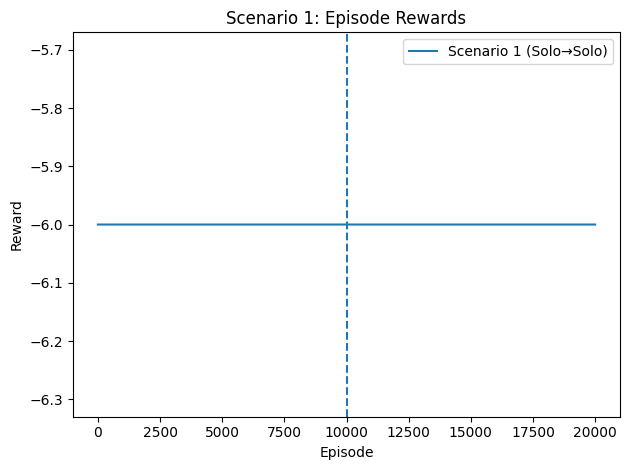

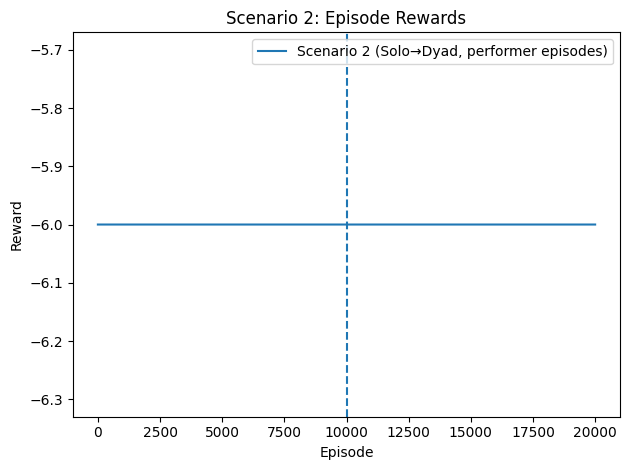

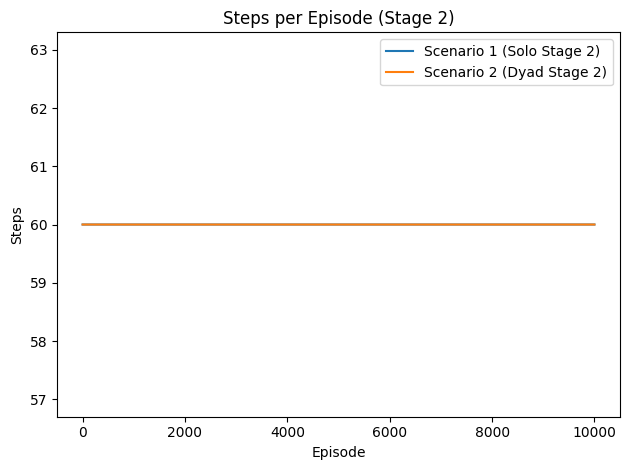

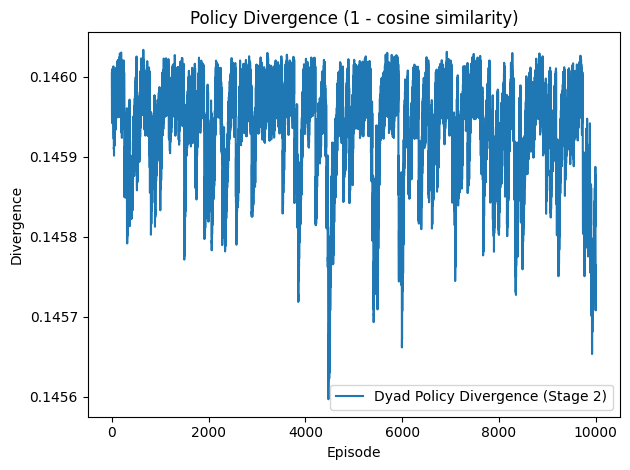

In [ ]:

import math
import random
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Optional, Tuple, List, Dict

# =====================================================
# Environment with Teacher-Constrained Exercise Sets
# =====================================================
class PianoEnv:
    """
    Sequential piece with L states. Each state has a correct action in [0, A-1].
    Teacher constrains actions via allowed_actions_map[state] (subset of actions).
    - If the agent chooses an action not in the allowed set: small penalty, no progress.
    - If the agent chooses the correct action (and it's allowed): reward +1 and advance.
    - Otherwise: small penalty, no progress.
    """
    def __init__(self, length: int = 12, n_actions: int = 7, max_steps: Optional[int] = None, seed: int = 0,
                 allowed_actions_map: Optional[List[List[int]]] = None):
        self.length = length
        self.n_actions = n_actions
        self.state = 0
        self.rng = random.Random(seed)
        self.np_rng = np.random.default_rng(seed)
        self.correct_map = [self.rng.randrange(n_actions) for _ in range(length)]
        self.max_steps = max_steps if max_steps is not None else 5 * length

        # If not provided, allow all actions at all states
        if allowed_actions_map is None:
            self.allowed_actions_map = [list(range(n_actions)) for _ in range(length)]
        else:
            # Ensure non-empty allowed sets
            self.allowed_actions_map = [aa if len(aa) > 0 else [self.rng.randrange(n_actions)] for aa in allowed_actions_map]

    def allowed_actions(self, state: int) -> List[int]:
        return self.allowed_actions_map[state]

    def reset(self) -> int:
        self.state = 0
        self.steps = 0
        return self.state

    def step(self, action: int) -> Tuple[int, float, bool, Dict]:
        self.steps += 1
        done = False
        reward = -0.1  # small penalty for non-progress actions

        # Validate against allowed set
        if action not in self.allowed_actions(self.state):
            # invalid under exercise constraints: slightly larger penalty
            reward = -0.2
        else:
            # within allowed set
            if action == self.correct_map[self.state]:
                reward = 1.0
                self.state += 1
                if self.state >= self.length:
                    done = True
            else:
                reward = -0.1

        if self.steps >= self.max_steps:
            done = True

        return self.state, reward, done, {}

# =====================================================
# Q-Learning Agent with Role-Based Updating
# =====================================================
@dataclass
class TalentProfile:
    alpha_init: float = 0.45
    alpha_decay: float = 0.001
    epsilon_init: float = 0.35
    epsilon_min: float = 0.02
    epsilon_decay: float = 0.0025
    gamma: float = 0.95
    name: str = "learner"

class QLearningAgent:
    def __init__(self, n_states: int, n_actions: int, talent: TalentProfile, seed: int = 0):
        self.n_states = n_states
        self.n_actions = n_actions
        self.talent = talent
        self.rng = random.Random(seed)
        self.np_rng = np.random.default_rng(seed)
        self.Q = self.np_rng.normal(loc=0.0, scale=0.01, size=(n_states, n_actions))
        self.episode = 0

    def epsilon(self) -> float:
        return max(self.talent.epsilon_min,
                   self.talent.epsilon_init * math.exp(-self.talent.epsilon_decay * self.episode))

    def alpha(self) -> float:
        return max(0.05, self.talent.alpha_init * math.exp(-self.talent.alpha_decay * self.episode))

    def start_episode(self):
        self.episode += 1

    def act(self, state: int, allowed_actions: List[int]) -> int:
        # Epsilon-greedy constrained to allowed_actions
        if self.rng.random() < self.epsilon():
            return self.rng.choice(allowed_actions)
        # Exploit: mask disallowed actions
        q = self.Q[state].copy()
        mask = np.full_like(q, -np.inf, dtype=float)
        mask[allowed_actions] = q[allowed_actions]
        return int(np.argmax(mask))

    def update_role_based(self, s: int, a: int, r: float, s_next: int, done: bool,
                          role: str = "performer", obs_factor: float = 0.3):
        if role == "performer":
            alpha = self.alpha()
        elif role == "coach":
            alpha = obs_factor * self.alpha()
        else:
            raise ValueError("role must be 'performer' or 'coach'")
        target = r + (0.0 if done else self.talent.gamma * np.max(self.Q[s_next]))
        self.Q[s, a] += alpha * (target - self.Q[s, a])

    def generate_action(self, state, allowed_actions):
        """Select an action from current Q-policy without updating epsilon."""
        q_values = [self.Q[state, a] for a in allowed_actions]
        return allowed_actions[int(np.argmax(q_values))]

# =====================================================
# Curricular Constraints (Teacher-Defined Allowed Actions)
# =====================================================
def build_allowed_actions_map(length: int, n_actions: int, seed: int = 0, restrict_ratio: float = 0.6):
    """
    Build per-state allowed action sets. Each state allows a subset (~restrict_ratio) of actions.
    This simulates a teacher-curated exercise set. The subset remains fixed across stages.
    """
    rng = random.Random(seed)
    allowed = []
    k = max(2, int(round(restrict_ratio * n_actions)))  # at least 2 actions per state
    for _ in range(length):
        actions = list(range(n_actions))
        rng.shuffle(actions)
        allowed.append(sorted(actions[:k]))
    return allowed

# =====================================================
# Training Routines
# =====================================================
def run_solo(env: PianoEnv, agent: QLearningAgent, n_episodes: int, seed: int = 0):
    rng = random.Random(seed)
    rewards = []
    steps_list = []
    for ep in range(n_episodes):
        agent.start_episode()
        s = env.reset()
        done = False
        ep_reward = 0.0
        steps = 0
        while not done:
            steps += 1
            a = agent.act(s, env.allowed_actions(s))
            s_next, r, done, _ = env.step(a)
            agent.update_role_based(s, a, r, s_next, done, role="performer")
            ep_reward += r
            s = s_next
        rewards.append(ep_reward)
        steps_list.append(steps)
    return {"rewards": np.array(rewards), "steps": np.array(steps_list)}

@dataclass
class DyadConfig:
    swap_every_step: bool = False
    obs_factor: float = 0.3  # coach learns weaker than performer

def run_dyad(env: PianoEnv, a: QLearningAgent, b: QLearningAgent,
             n_episodes: int, cfg: DyadConfig, seed: int = 0):
    rng = random.Random(seed)
    rewards_performer = []
    steps_list = []
    divergence = []

    for ep in range(n_episodes):
        a.start_episode()
        b.start_episode()
        s = env.reset()
        done = False
        ep_reward = 0.0
        steps = 0

        performer_first_is_a = (ep % 2 == 0)
        performer = a if performer_first_is_a else b
        coach = b if performer_first_is_a else a

        while not done:
            steps += 1
            allowed = env.allowed_actions(s)

            # Performer acts from own policy (epsilon-greedy)
            action = performer.act(s, allowed)

            # Coach generates action from its own Q policy
            coach_action = coach.generate_action(s, allowed)

            # If you want, you could measure similarity between actions here:
            # action_match = (action == coach_action)

            s_next, r, done, _ = env.step(action)

            # Performer updates strongly
            performer.update_role_based(s, action, r, s_next, done, role="performer")
            # Coach updates cautiously
            coach.update_role_based(s, coach_action, r, s_next, done, role="coach", obs_factor=cfg.obs_factor)

            ep_reward += r
            s = s_next

            if cfg.swap_every_step:
                performer, coach = coach, performer

            if done:
                break

        rewards_performer.append(ep_reward)
        steps_list.append(steps)

        flat_a = a.Q.flatten()
        flat_b = b.Q.flatten()
        denom = (np.linalg.norm(flat_a) * np.linalg.norm(flat_b) + 1e-12)
        cos_sim = float(np.dot(flat_a, flat_b) / denom)
        divergence.append(1.0 - cos_sim)

    return {
        "rewards_performer": np.array(rewards_performer),
        "steps": np.array(steps_list),
        "divergence": np.array(divergence)
    }

# def run_dyad_old(env: PianoEnv, a: QLearningAgent, b: QLearningAgent,
#              n_episodes: int, cfg: DyadConfig, seed: int = 0):
#     rng = random.Random(seed)
#     rewards_performer = []
#     steps_list = []
#     divergence = []

#     for ep in range(n_episodes):
#         a.start_episode()
#         b.start_episode()
#         s = env.reset()
#         done = False
#         ep_reward = 0.0
#         steps = 0

#         performer_first_is_a = (ep % 2 == 0)
#         performer = a if performer_first_is_a else b
#         coach = b if performer_first_is_a else a

#         while not done:
#             steps += 1
#             allowed = env.allowed_actions(s)
#             action = performer.act(s, allowed)
#             s_next, r, done, _ = env.step(action)

#             # Updates
#             performer.update_role_based(s, action, r, s_next, done, role="performer")
#             coach.update_role_based(s, action, r, s_next, done, role="coach", obs_factor=cfg.obs_factor)

#             ep_reward += r
#             s = s_next

#             if cfg.swap_every_step:
#                 performer, coach = coach, performer

#             if done:
#                 break

#         rewards_performer.append(ep_reward)
#         steps_list.append(steps)

#         # Track policy divergence after each dyad episode
#         flat_a = a.Q.flatten()
#         flat_b = b.Q.flatten()
#         denom = (np.linalg.norm(flat_a) * np.linalg.norm(flat_b) + 1e-12)
#         cos_sim = float(np.dot(flat_a, flat_b) / denom)
#         divergence.append(1.0 - cos_sim)

#     return {"rewards_performer": np.array(rewards_performer),
#             "steps": np.array(steps_list),
#             "divergence": np.array(divergence)}

# =====================================================
# Experiment: Two Scenarios, Two Stages
# =====================================================
@dataclass
class ExperimentConfig:
    length: int = 12
    n_actions: int = 7
    episodes_stage1: int = 150
    episodes_stage2: int = 150
    seed: int = 7
    restrict_ratio: float = 0.6
    obs_factor: float = 0.3
    swap_every_step: bool = False

def make_talents():
    # Distinct talents (fixed individuality)
    tA = TalentProfile(alpha_init=0.5, alpha_decay=0.001, epsilon_init=0.25, epsilon_min=0.02,
                       epsilon_decay=0.003, gamma=0.95, name="Learner A")
    tB = TalentProfile(alpha_init=0.35, alpha_decay=0.0008, epsilon_init=0.4, epsilon_min=0.05,
                       epsilon_decay=0.002, gamma=0.90, name="Learner B")
    tS = TalentProfile(alpha_init=0.45, alpha_decay=0.0015, epsilon_init=0.35, epsilon_min=0.03,
                       epsilon_decay=0.0025, gamma=0.92, name="Solo")
    return tA, tB, tS

def clone_env_with_constraints(base_env: PianoEnv):
    e = PianoEnv(length=base_env.length, n_actions=base_env.n_actions, seed=0,
                 allowed_actions_map=[aa[:] for aa in base_env.allowed_actions_map])
    e.correct_map = base_env.correct_map[:]
    e.max_steps = base_env.max_steps
    return e

def episodes_to_master(rewards_arr: np.ndarray, threshold: float) -> Optional[int]:
    for i, r in enumerate(rewards_arr):
        if r >= threshold:
            return i + 1
    return None

def run_experiment(cfg: ExperimentConfig):
    # Teacher-constraints are identical across scenarios and both stages
    allowed_actions_map = build_allowed_actions_map(cfg.length, cfg.n_actions, seed=cfg.seed, restrict_ratio=cfg.restrict_ratio)
    base_env = PianoEnv(length=cfg.length, n_actions=cfg.n_actions, seed=cfg.seed,
                        allowed_actions_map=allowed_actions_map)

    # --------------------
    # Scenario 1: Solo -> Solo
    # --------------------
    env1_stage1 = clone_env_with_constraints(base_env)
    env1_stage2 = clone_env_with_constraints(base_env)

    _, _, tS = make_talents()
    solo_agent = QLearningAgent(cfg.length, cfg.n_actions, tS, seed=cfg.seed + 1)

    # Stage 1 (solo, constrained)
    res1_s1 = run_solo(env1_stage1, solo_agent, n_episodes=cfg.episodes_stage1, seed=cfg.seed + 10)
    # Stage 2 (solo continuation, constrained)
    res1_s2 = run_solo(env1_stage2, solo_agent, n_episodes=cfg.episodes_stage2, seed=cfg.seed + 11)

    scenario1 = {
        "stage1": res1_s1,
        "stage2": res1_s2,
        "agent": solo_agent,
    }

    # --------------------
    # Scenario 2: Solo -> Dyad (two distinct learners)
    # --------------------
    env2_stage1_A = clone_env_with_constraints(base_env)
    env2_stage1_B = clone_env_with_constraints(base_env)
    env2_stage2 = clone_env_with_constraints(base_env)

    tA, tB, _ = make_talents()
    A = QLearningAgent(cfg.length, cfg.n_actions, tA, seed=cfg.seed + 2)
    B = QLearningAgent(cfg.length, cfg.n_actions, tB, seed=cfg.seed + 3)

    # Stage 1: both A and B train SOLO independently (same constraints)
    res2A_s1 = run_solo(env2_stage1_A, A, n_episodes=cfg.episodes_stage1, seed=cfg.seed + 20)
    res2B_s1 = run_solo(env2_stage1_B, B, n_episodes=cfg.episodes_stage1, seed=cfg.seed + 21)

    # Stage 2: A and B train in DYAD with role-based update strengths
    dyad_cfg = DyadConfig(swap_every_step=cfg.swap_every_step, obs_factor=cfg.obs_factor)
    res2_dyad = run_dyad(env2_stage2, A, B, n_episodes=cfg.episodes_stage2, cfg=dyad_cfg, seed=cfg.seed + 22)

    scenario2 = {
        "A_stage1": res2A_s1,
        "B_stage1": res2B_s1,
        "stage2_dyad": res2_dyad,
        "A": A,
        "B": B,
    }

    # --------------------
    # Summaries
    # --------------------
    length = cfg.length
    mastery_thresh = 0.9 * length  

    def summarize_last50(rewards):
        last = rewards[-50:] if len(rewards) >= 50 else rewards
        return float(np.mean(last))

    summary = {
        "scenario1": {
            "mean_reward_last50_stage2": summarize_last50(scenario1["stage2"]["rewards"]),
            "mean_steps_last50_stage2": float(np.mean(scenario1["stage2"]["steps"][-50:])),
            "episodes_to_mastery_stage1": episodes_to_master(scenario1["stage1"]["rewards"], mastery_thresh),
            "episodes_to_mastery_stage2": episodes_to_master(scenario1["stage2"]["rewards"], mastery_thresh),
        },
        "scenario2_dyad": {
            "mean_reward_last50_stage2": summarize_last50(scenario2["stage2_dyad"]["rewards_performer"]),
            "mean_steps_last50_stage2": float(np.mean(scenario2["stage2_dyad"]["steps"][-50:])),
            "episodes_to_mastery_stage1_A": episodes_to_master(scenario2["A_stage1"]["rewards"], mastery_thresh),
            "episodes_to_mastery_stage1_B": episodes_to_master(scenario2["B_stage1"]["rewards"], mastery_thresh),
            "episodes_to_mastery_stage2_dyad": episodes_to_master(scenario2["stage2_dyad"]["rewards_performer"], mastery_thresh),
        },
        "mastery_threshold": mastery_thresh
    }

    return {"scenario1": scenario1, "scenario2": scenario2, "summary": summary, "env": base_env}

# =====================================================
# Plotting
# =====================================================
def plot_experiment(out, cfg: ExperimentConfig):
    s1 = out["scenario1"]
    s2 = out["scenario2"]

    # 1) Scenario 1: reward curve (stage1+stage2)
    plt.figure()
    rewards1 = np.concatenate([s1["stage1"]["rewards"], s1["stage2"]["rewards"]])
    plt.plot(rewards1, label="Scenario 1 (Solo→Solo)")
    plt.axvline(x=len(s1["stage1"]["rewards"]) - 1, linestyle="--")
    plt.title("Scenario 1: Episode Rewards")
    plt.xlabel("Episode")
    plt.ylabel("Reward")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 2) Scenario 2: dyad rewards (performer episodes)
    plt.figure()
    rewards2 = np.concatenate([
        (s2["A_stage1"]["rewards"] + s2["B_stage1"]["rewards"]) / 2.0,  # average of A and B stage1
        s2["stage2_dyad"]["rewards_performer"]
    ])
    plt.plot(rewards2, label="Scenario 2 (Solo→Dyad, performer episodes)")
    plt.axvline(x=len(s2["A_stage1"]["rewards"]) - 1, linestyle="--")
    plt.title("Scenario 2: Episode Rewards")
    plt.xlabel("Episode")
    plt.ylabel("Reward")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 3) Steps per episode comparison (Stage 2 only)
    plt.figure()
    plt.plot(s1["stage2"]["steps"], label="Scenario 1 (Solo Stage 2)")
    plt.plot(s2["stage2_dyad"]["steps"], label="Scenario 2 (Dyad Stage 2)")
    plt.title("Steps per Episode (Stage 2)")
    plt.xlabel("Episode")
    plt.ylabel("Steps")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 4) Dyad policy divergence over Stage 2
    plt.figure()
    plt.plot(s2["stage2_dyad"]["divergence"], label="Dyad Policy Divergence (Stage 2)")
    plt.title("Policy Divergence (1 - cosine similarity)")
    plt.xlabel("Episode")
    plt.ylabel("Divergence")
    plt.legend()
    plt.tight_layout()
    plt.show()

# =====================================================
# Main
# =====================================================
def main():
    cfg = ExperimentConfig(
        length=12,
        n_actions=7,
        episodes_stage1=100,
        episodes_stage2=100,
        seed=7,
        restrict_ratio=0.6,
        obs_factor=0.3,
        swap_every_step=True
    )
    out = run_experiment(cfg)

    # Print summary
    print("=== Summary (Stage 2 focus) ===")
    for k, v in out["summary"].items():
        if k == "mastery_threshold":
            continue
        print(f"[{k}]")
        for kk, vv in v.items():
            print(f"  {kk}: {vv}")
    print(f"\nMastery threshold (reward): {out['summary']['mastery_threshold']:.2f}")

    # Plots
    plot_experiment(out, cfg)

if __name__ == "__main__":
    main()
